In [1]:
# Load necessary Libraries.

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import GlobalAveragePooling2D

from tensorflow.keras.layers import Dense

from tensorflow.keras.layers import Dropout

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt

In [2]:
# Load the trained model.

dataset_path = "DataSet"

image_generator = ImageDataGenerator(

    rescale=1/255,

    validation_split=0.2,

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True
)

train_data = image_generator.flow_from_directory(

    dataset_path,

    target_size=(224,224),

    batch_size=16,

    class_mode='binary',

    subset='training'
)

validation_data = image_generator.flow_from_directory(

    dataset_path,

    target_size=(224,224),

    batch_size=16,

    class_mode='binary',

    subset='validation'
)

Found 2172 images belonging to 2 classes.
Found 542 images belonging to 2 classes.


In [3]:
# Print class indices to verify the mapping of classes to labels.

print(train_data.class_indices)

{'Fresh_Food': 0, 'Spoiled_Food': 1}


In [4]:
# Load the MobileNetV2 model without the top layer and with pre-trained ImageNet weights.

base_model = MobileNetV2(

    weights='imagenet',

    include_top=False,

    input_shape=(224,224,3)
)

# Fine Tuning
base_model.trainable = True

# Freeze Most Layers
for layer in base_model.layers[:-30]:

    layer.trainable = False

model = Sequential()

model.add(base_model)

model.add(GlobalAveragePooling2D())

model.add(Dense(

    128,

    activation='relu'
))

model.add(Dropout(0.5))

model.add(Dense(

    1,

    activation='sigmoid'
))

In [5]:
# Compile the model with a lower learning rate for fine-tuning.

model.compile(

    optimizer=Adam(learning_rate=0.0001),

    loss='binary_crossentropy',

    metrics=['accuracy']
)

In [6]:
# Define Early Stopping Callback.

early_stop = EarlyStopping(

    monitor='val_loss',

    patience=2,

    restore_best_weights=True
)

In [7]:
# Train the model with early stopping.

history = model.fit(

    train_data,

    validation_data=validation_data,

    epochs=25,
)

Epoch 1/25
136/136 ━━━━━━━━━━━━━━━━━━━━ 85s 572ms/step - accuracy: 0.7012 - loss: 0.5794 - val_accuracy: 0.7066 - val_loss: 0.6168
Epoch 2/25
136/136 ━━━━━━━━━━━━━━━━━━━━ 74s 543ms/step - accuracy: 0.8085 - loss: 0.4118 - val_accuracy: 0.6937 - val_loss: 0.5851
Epoch 3/25
136/136 ━━━━━━━━━━━━━━━━━━━━ 78s 574ms/step - accuracy: 0.8646 - loss: 0.3306 - val_accuracy: 0.7288 - val_loss: 0.5661
Epoch 4/25
136/136 ━━━━━━━━━━━━━━━━━━━━ 82s 606ms/step - accuracy: 0.8835 - loss: 0.2700 - val_accuracy: 0.7417 - val_loss: 0.5965
Epoch 5/25
136/136 ━━━━━━━━━━━━━━━━━━━━ 78s 575ms/step - accuracy: 0.8927 - loss: 0.2555 - val_accuracy: 0.7528 - val_loss: 0.6196
Epoch 6/25
136/136 ━━━━━━━━━━━━━━━━━━━━ 81s 598ms/step - accuracy: 0.9157 - loss: 0.2062 - val_accuracy: 0.7362 - val_loss: 0.6489
Epoch 7/25
136/136 ━━━━━━━━━━━━━━━━━━━━ 80s 590ms/step - accuracy: 0.9250 - loss: 0.1862 - val_accuracy: 0.7417 - val_loss: 0.7204
Epoch 8/25
136/136 ━━━━━━━━━━━━━━━━━━━━ 74s 543ms/step - accuracy: 0.9526 - loss: 0

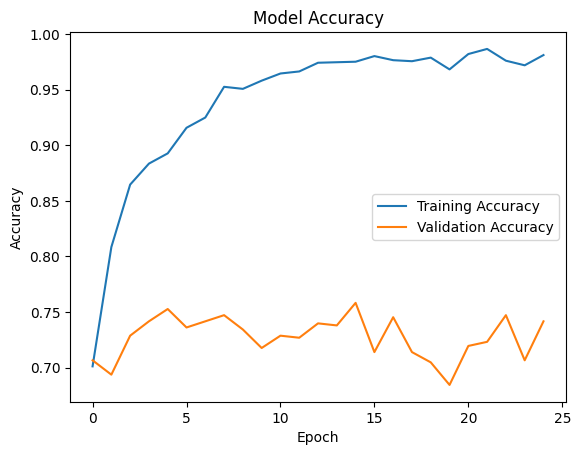

In [10]:
# Plot training and validation accuracy.

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend([
    
    "Training Accuracy",
    
    "Validation Accuracy"
])

plt.show()

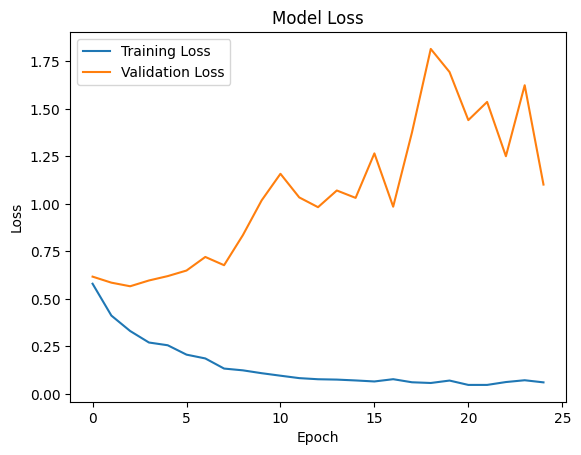

In [11]:
# Plot training and validation loss.

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend([
    
    "Training Loss",
    
    "Validation Loss"
])

plt.show()

In [12]:
# Plot training and validation loss.

model.save("food_quality_model.keras")